In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # [-1,1]
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


100%|██████████| 170M/170M [00:05<00:00, 31.1MB/s]


In [ ]:
class EncoderDecoderCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 32x32 → 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 16x16 → 8x8
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8x8 → 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 16x16 → 32x32
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EncoderDecoderCNN().to(device)

# Choose ONE
criterion = nn.MSELoss()   # or nn.L1Loss()

optimizer = optim.Adam(model.parameters(), lr=0.0002)


In [ ]:
epochs = 10

for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.0200
Epoch [2/10], Loss: 0.0041
Epoch [3/10], Loss: 0.0028
Epoch [4/10], Loss: 0.0022
Epoch [5/10], Loss: 0.0019
Epoch [6/10], Loss: 0.0016
Epoch [7/10], Loss: 0.0014
Epoch [8/10], Loss: 0.0012
Epoch [9/10], Loss: 0.0011
Epoch [10/10], Loss: 0.0010


In [ ]:
def show_images(input_img, output_img):
    input_img = (input_img * 0.5 + 0.5).cpu().detach()
    output_img = (output_img * 0.5 + 0.5).cpu().detach()

    fig, axes = plt.subplots(2, 5, figsize=(12,5))
    for i in range(5):
        axes[0, i].imshow(input_img[i].permute(1,2,0))
        axes[0, i].set_title("Input")
        axes[0, i].axis("off")

        axes[1, i].imshow(output_img[i].permute(1,2,0))
        axes[1, i].set_title("Output")
        axes[1, i].axis("off")

    plt.show()


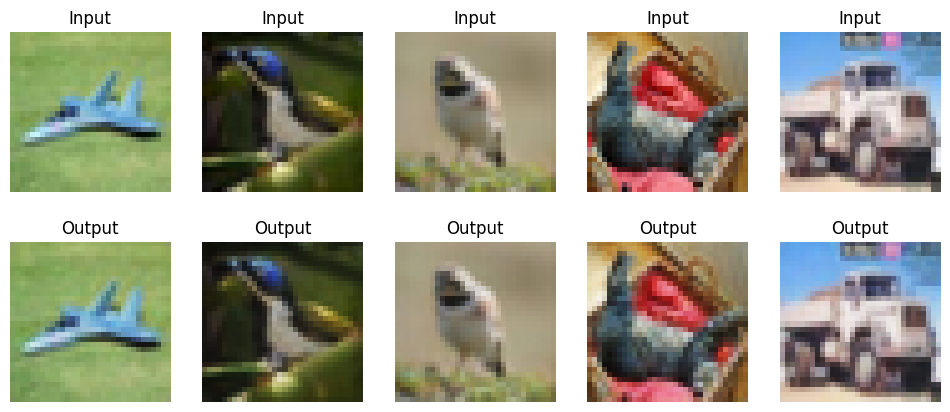

In [ ]:
dataiter = iter(train_loader)
images, _ = next(dataiter)
images = images.to(device)

outputs = model(images)

show_images(images, outputs)
